In [1]:
import torch
import stable_worldmodel as swm
from sigreg import SIGReg 
from torch.distributions.normal import Normal
from torch.linalg import vector_norm
from model import WorldModel
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F
from stable_worldmodel.wm.utils import save_pretrained
from omegaconf import OmegaConf

In [2]:
device = 'mps'
num_epochs = 10

In [3]:
dataset = swm.data.load_dataset(
    'tworooms-big.lance',
    num_steps=5,
    frameskip=1,
    keys_to_load=['pixels', 'action', 'state'],
)

In [4]:
action_dim = 2

In [5]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    drop_last=True,
)

In [6]:
model = WorldModel(
    hidden_dim=192, 
    patch_size=14,
    channels=3, 
    enc_nb_heads=3, 
    enc_nb_layers=12, 
    height=224, 
    width=224, 
    pred_nb_layers=6, 
    pred_p_dropout=0.1, 
    pred_nb_heads=16, 
    action_dim=action_dim
).to(device)

In [7]:
#model = model.load_state_dict(torch.load('./model-1.pt'))

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [8]:
losses = []
sigreg_losses = []
mse_losses = []

In [9]:
for epoch in tqdm(range(num_epochs), desc="training"):
    for batch in loader:
        optimizer.zero_grad()
        frames = batch['pixels'].to(device).type(torch.float32)
        actions = torch.nan_to_num(batch['action'], 0.0).to(device).type(torch.float32)
        pred, embeds = model(frames, actions)
        sigregloss = SIGReg(embeds.reshape(-1, embeds.shape[-1]))
        mseloss = F.mse_loss(pred[:,0:-2,:], embeds[:,1:-1,:])
        loss = mseloss + 0.1*sigregloss
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        sigreg_losses.append(sigregloss)
        mse_losses.append(mseloss)
    scheduler.step()

training:  10%|███████████████▊                                                                                                                                              | 1/10 [37:28<5:37:20, 2248.96s/it]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x109bbaca0>
Traceback (most recent call last):
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1686, in __del__
    self._shutdown_workers()
  File "/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1650, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aa

In [10]:
import matplotlib.pyplot as plt

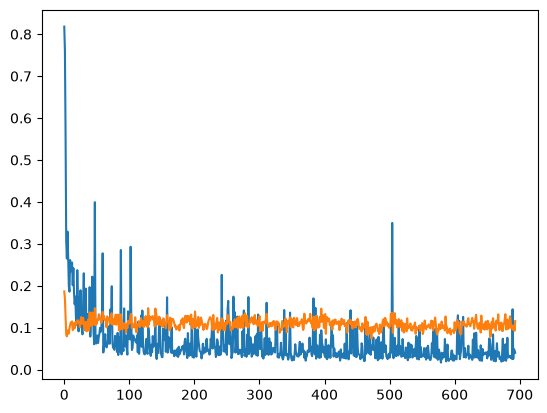

In [14]:
plt.plot(losses, label="loss")
plt.plot([s.item() for s in sigreg_losses], label="sigreg")
plt.plot([s.item() for s in mse_losses], label="mse")

In [15]:
torch.save(model.state_dict(), f'tworoom-big-{num_epochs}.pt')

In [16]:
model_config = OmegaConf.create({
    '_target_': 'model.WorldModel',
    'hidden_dim': 192,
    'action_dim': 2,
    'patch_size': 14,
    'channels':3, 
    'enc_nb_heads':3, 
    'enc_nb_layers':12, 
    'height':224, 
    'width':224, 
    'pred_nb_layers':6, 
    'pred_p_dropout':0.1, 
    'pred_nb_heads':16
})

save_pretrained(
    model=model,
    run_name='bigtworoomwm',
    config=model_config,
    filename='weights.pt',
)


2026-06-15 11:41:44.907 | INFO     | stable_worldmodel.wm.utils:save_pretrained:42 - 📦📦📦 Model saved to /Users/matheoledevehat/.stable_worldmodel/checkpoints/bigtworoomwm/weights.pt 📦📦📦


In [15]:
def CEM(model, H, N, K, T, action_dim, start, goal):
    means = [torch.zeros(H, action_dim).to(device)]
    stds = [torch.ones(H, action_dim).to(device)]
    best_action_sequence, min_cost = None, float('inf')
    for t in range(T):
        distribution = Normal(means[-1], stds[-1])
        candidates = distribution.sample((N,)).to(device)
        destinations = model.rollout(start, candidates, H)
        costs = vector_norm((goal.expand(N, -1) - destinations), dim=1)
        elite_costs, elite = torch.topk(costs, k=K, largest=False)
        mean = candidates[elite].mean(dim=0)
        std = candidates[elite].std(dim=0)
        means.append(mean)
        stds.append(std)
        if elite_costs[0] < min_cost:
            best_action_sequence = candidates[elite[0]]
            min_cost = elite_costs[0]
    return best_action_sequence

In [16]:
batch = next(iter(loader))

In [17]:
frames = batch['pixels'].to(device).type(torch.float32)

In [18]:
with torch.no_grad():
    model.eval()
    start = model.encode_frames(frames[0][0].expand(1, 1, -1, -1, -1))
    goal = model.encode_frames(frames[0][-1].expand(1, 1, -1, -1, -1))

In [19]:
CEM(model, H=5, N=300, K=30, T=30, action_dim=action_dim, start=start.view(1, -1), goal=goal.view(1, -1))

tensor([[-0.1575,  0.6617],
        [ 1.2962,  0.5821],
        [-0.2465,  0.7406],
        [-0.3448,  0.7403],
        [-0.3750,  0.7281]], device='mps:0')